In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info, compute_gap_in_percentage_list_keep_name
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
def deduplicate_metrics(search_results):
    records_length_so_far = {}
    new_search_results = {}
    for key, value in search_results.items():
        if value['record'] not in records_length_so_far:
            records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
            new_search_results[key] = value
        else:
            if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
                new_search_results.pop(records_length_so_far[value['record']][1])

                records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
                new_search_results[key] = value
    return new_search_results



In [3]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
#         #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
#     ]
# )
with open('june1.cache', 'r') as f:
    ori_results = json.load(f)

In [4]:
folder_info = ori_results

In [5]:
len(folder_info)

5409

In [7]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}
# for each search algo, we get the R1 and O3 with level 1, 12, 125 results for plotting
# thats 6 results for each search algo, so we plot with 3 columns (level) and 2 rows (R1 and O3)

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini', 'gemini-2.5-pro']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 29
flat z o3-mini 60
flat z gemini-2.5-pro 57
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 1 gemini-2.5-pro 57
flat 2 deepseek-r1 29
flat 2 o3-mini 60
flat 2 gemini-2.5-pro 57
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 5 gemini-2.5-pro 57
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 12 gemini-2.5-pro 57
flat 125 deepseek-r1 75
flat 125 o3-mini 55
flat 125 gemini-2.5-pro 57
tree z deepseek-r1 29
tree z o3-mini 60
tree z gemini-2.5-pro 55
tree 1 deepseek-r1 27
tree 1 o3-mini 106
tree 1 gemini-2.5-pro 57
tree 2 deepseek-r1 29
tree 2 o3-mini 60
tree 2 gemini-2.5-pro 57
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 5 gemini-2.5-pro 57
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 12 gemini-2.5-pro 47
tree 125 deepseek-r1 75
tree 125 o3-mini 74
tree 125 gemini-2.5-pro 49
forest z deepseek-r1 29
forest z o3-mini 60
forest z gemini-2.5-pro 57
forest 1 deepseek-r1 27
forest 1 o3-mini 106
forest 1 gemini-2.5-pro 57
forest 2 deepseek-r1 29
forest 2 o3-mini 60
forest 2 gemin

In [8]:
from tqdm import tqdm
from itertools import product

In [12]:
figure_data = {}
# for search_algo in search_algo_params.keys():
#     for level in ['z', 1, 2, 5, 12, 125]:
#         # for model in ['o3-mini']:
#         for model in ['deepseek-r1', 'o3-mini']:
#             plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
#             # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
#             figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
for search_algo, level, model in tqdm(product(
    search_algo_params.keys(),
    ['z', 1, 2, 5, 12, 125],
    ['deepseek-r1', 'o3-mini', 'gemini-2.5-pro']
)):
    plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
    # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
    figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)

90it [04:20,  2.89s/it]


In [13]:
import torch

In [14]:
torch.save(plot_info, 'plot_info.pt')
torch.save(figure_data, 'figure_data.pt')

In [15]:
plot_info = torch.load('plot_info.pt')
figure_data = torch.load('figure_data.pt')

/tmp/ipykernel_3038028/2014321233.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  plot_info = torch.load('plot_info.pt')
/tmp/ipykernel_3038028/2014321233.py:2: FutureWa

In [16]:
# Record	Train Time std
# 1	20183.68
# 2	18300.36
# 3	22270.99
# 4	37980.47
# 5	7365.53
# 6	5922.16
# 7	3805.14
# 8	9496.43
# 9	15747.18
# 10	2315.29
# 11	3259.97
# 12	1220.16
# 13	927.61
# 14	6034.27
# 15	2337.85
# 16	6700.25
# 17	40.5
# 18	1495.18
# 19	600.67
# 20	770.64
# 21	593.64
train_time_std = {
    1: 20183.68,
    2: 18300.36, 
    3: 22270.99,
    4: 37980.47,
    5: 7365.53,
    6: 5922.16,
    7: 3805.14,
    8: 9496.43,
    9: 15747.18,
    10: 2315.29,
    11: 3259.97,
    12: 1220.16,
    13: 927.61,
    14: 6034.27,
    15: 2337.85,
    16: 6700.25,
    17: 40.5,
    18: 1495.18,
    19: 600.67,
    20: 770.64,
    21: 593.64
}

In [17]:
human_train_time_dict

{1: 2968348,
 2: 2209926,
 3: 1386147,
 4: 1301740,
 5: 949528,
 6: 766259,
 7: 773072,
 8: 662205,
 9: 505531,
 10: 477150,
 11: 442985,
 12: 317839,
 13: 289805,
 14: 273107,
 15: 241463,
 16: 232971,
 17: 220374,
 18: 211840,
 19: 199442,
 20: 188680,
 21: 184262}

In [18]:

gaps = {}
for k, v in human_train_time_dict.items():
    if (k + 1) not in human_train_time_dict:
        continue
    gaps[k] = v - human_train_time_dict[k+1]

In [19]:
std_percentage = {}
for k, v in gaps.items():
    std_percentage[k] = train_time_std[k] / v
std_percentage


{1: 0.026612730115951277,
 2: 0.022215132942209014,
 3: 0.2638524056061701,
 4: 0.1078341169522901,
 5: 0.040189721120320404,
 6: -0.8692440921767209,
 7: 0.034321664697340055,
 8: 0.06061267344932791,
 9: 0.5548493710581023,
 10: 0.06776789111663983,
 11: 0.02604933437744714,
 12: 0.04352429193122637,
 13: 0.055552161935561145,
 14: 0.190692390342561,
 15: 0.27530028261893547,
 16: 0.5318925140906565,
 17: 0.004745722990391376,
 18: 0.12059848362639136,
 19: 0.055813975097565506,
 20: 0.17443186962426438}

In [20]:
figure_data_percent = {}
for key in figure_data.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_z_deepseek-r1
flat_z_o3-mini
flat_z_gemini-2.5-pro
flat_1_deepseek-r1
flat_1_o3-mini
flat_1_gemini-2.5-pro
flat_2_deepseek-r1
flat_2_o3-mini
flat_2_gemini-2.5-pro
flat_5_deepseek-r1
flat_5_o3-mini
flat_5_gemini-2.5-pro
flat_12_deepseek-r1
flat_12_o3-mini
flat_12_gemini-2.5-pro
flat_125_deepseek-r1
flat_125_o3-mini
flat_125_gemini-2.5-pro
tree_z_deepseek-r1
tree_z_o3-mini
tree_z_gemini-2.5-pro
tree_1_deepseek-r1
tree_1_o3-mini
tree_1_gemini-2.5-pro
tree_2_deepseek-r1
tree_2_o3-mini
tree_2_gemini-2.5-pro
tree_5_deepseek-r1
tree_5_o3-mini
tree_5_gemini-2.5-pro
tree_12_deepseek-r1
tree_12_o3-mini
tree_12_gemini-2.5-pro
tree_125_deepseek-r1
tree_125_o3-mini
tree_125_gemini-2.5-pro
forest_z_deepseek-r1
forest_z_o3-mini
forest_z_gemini-2.5-pro
forest_1_deepseek-r1
forest_1_o3-mini
forest_1_gemini-2.5-pro
forest_2_deepseek-r1
forest_2_o3-mini
forest_2_gemini-2.5-pro
forest_5_deepseek-r1
forest_5_o3-mini
forest_5_gemini-2.5-pro
forest_12_deepseek-r1
forest_12_o3-mini
forest_12_gemini-2.5-p

In [21]:
# Process each config and compute mean/sem for each experiment
results_by_config = {}
for config, experiments in figure_data_percent.items():
    # Process each experiment
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
        results_by_config[config] = {
            # 'values': [],
            'means': [],
            'sems': []
        }
        continue
        
    experiment_values = {}
    for exp_name, values in experiments.items():
        # Filter out invalid values
        valid_values = []
        for x in values:
            if not (0 <= x <= 3):
                print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
                valid_values.append(0)
            else:
                valid_values.append(x)
                
        if len(valid_values) == 0:
            print(f"Warning: No valid values for {config} {exp_name}")
            experiment_values[exp_name] = {
                # 'values': np.array([0]),
                'mean': 0,
                'sem': 0
            }
        else:
            values_arr = np.array(valid_values)
            experiment_values[exp_name] = {
                # 'values': values_arr,
                'mean': np.mean(values_arr),
                'sem': np.std(values_arr) / np.sqrt(len(values_arr))
            }
    # Store results
    results_by_config[config] = {
        # 'values': [exp['values'] for exp in experiment_values.values()],
        'means': {k: v for k, v in experiment_values.items()},
        'sems': {k: v for k, v in experiment_values.items()}
    }


In [22]:

import matplotlib.pyplot as plt
import math
import numpy as np

def plot_gap_comparison(
    data_dicts, 
    data_stds=None,
    std_dicts=None,
    figsize=(10, 5), 
    n_cols=None, 
    main_title='Recovered Time Percentage Comparison With Paper-Like Prompt',
    x_label='Record Number',
    y_label='$\overline{FSR}$',
    ):
    """
    Create a subplot visualization comparing gap percentages with adaptive layout.
    
    Args:
        data_dicts: List of tuples containing (dictionary, title, color)
        figsize: Tuple of figure size (width, height)
        main_title: Main title for the entire figure
    """
    # Calculate the number of rows and columns for the subplot grid
    n_plots = len(data_dicts)
    if n_cols is None:
        n_cols = math.ceil(math.sqrt(n_plots))  # Square root for balanced layout
    n_rows = math.ceil(n_plots / n_cols)
    
    # Adjust figure size based on number of subplots
    width, height = figsize
    figsize = (width * (n_cols/2), height * (n_rows/2))
    
    # Create subplot layout with shared axes
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
    if n_plots == 1:
        axs = np.array([axs])
    axs = axs.flatten()  # Flatten the array to make indexing easier

    # Create a barplot for each dictionary
    for i, (data_dict, title, color) in enumerate(data_dicts):
        # Sort the dictionary by keys
        sorted_items = sorted(data_dict.items(), key=lambda x: int(x[0]))
        keys = [item[0] for item in sorted_items]
        values = [item[1] for item in sorted_items]
        
        # Create the barplot with the specified color
        if std_dicts is not None:
            # Get standard deviations for current dataset
            stds = [std_dicts[k] * 1.0 for k in keys]  # Scale to 100% reference
            bar_positions = np.arange(len(keys)) * 1.2
            bars = axs[i].bar(bar_positions, values, color=color, width=0.6, align='edge', edgecolor='black', alpha=0.8)
            # Add error bars on the bars themselves
            axs[i].errorbar(bar_positions, values, yerr=stds, fmt='none', color='black', capsize=5)
        elif data_stds is not None:
            stds = [data_stds[i][k] * 1.0 for k in keys]
            bar_positions = np.arange(len(keys)) * 1.3
            bars = axs[i].bar(bar_positions, values, color=color, edgecolor='black', alpha=0.8)
            axs[i].errorbar(bar_positions, values, yerr=stds, fmt='none', color='black', capsize=5)
        else:
            bar_positions = None
            bars = axs[i].bar(range(len(keys)), values, color=color, edgecolor='black', alpha=0.8)
        
        # Add title
        axs[i].set_title(title, fontsize=20)
        
        # Only add x and y labels for leftmost and bottom subplots
        if i % n_cols == 0:  # Leftmost subplot in each row
            axs[i].set_ylabel(y_label, fontsize=19)
        if i >= n_plots - n_cols:  # Bottom row
            axs[i].set_xlabel(x_label, fontsize=19)
        
        # Ensure all xticks are shown
        if bar_positions is not None:
            axs[i].set_xticks(bar_positions)
        else:
            axs[i].set_xticks(range(len(keys)))
        if i >= n_plots - n_cols:  # Only show x labels for bottom row
            axs[i].set_xticklabels(keys, fontsize=16)
        else:
            axs[i].set_xticklabels([])
        
        # Add grid for better readability
        axs[i].grid(True, linestyle='--', alpha=0.7)
        
        # Add a horizontal line at y=0
        axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        
        # Format y-axis as percentage (only for leftmost plots)
        if i % n_cols == 0:
            axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
            # Get the tick labels
            yticklabels = [item.get_text() for item in axs[i].get_yticklabels()]
            # Set the tick labels with rotation
            axs[i].set_yticklabels(yticklabels, rotation=90, fontsize=12, va='center')  # Rotate by 45 degrees
        # else:
        #     axs[i].set_yticklabels([])
        axs[i].set_ylim(0.0, 1.6)  # Set y-axis limits to -0.1 to 1.0 for all plots
        
        # Annotate the values on top of the bars
        for bar in bars:
            height = bar.get_height()
            if height >= 0:
                y_pos = height + 0.02
            else:
                y_pos = height - 0.05
            axs[i].text(
                bar.get_x() + bar.get_width()/2.,
                y_pos,
                '{:.1f}'.format(height * 100),
                ha='center', 
                fontsize=16,
                # fontweight='bold',
                color='black',
                # rotation=30,
            )
    
    # Hide empty subplots if any
    for i in range(n_plots, len(axs)):
        axs[i].set_visible(False)

    # Add a main title for the figure
    fig.suptitle(main_title, fontsize=20, y=0.97)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

    return fig, axs



<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3038028/960325575.py:13: SyntaxWarning: invalid escape sequence '\o'
  y_label='$\overline{FSR}$',


<>:52: SyntaxWarning: invalid escape sequence '\o'
<>:52: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3038028/315020909.py:52: SyntaxWarning: invalid escape sequence '\o'
  main_title='$\overline{FSR}$ Comparison:' + f' {search_algo_plot[search_algo]}'
/tmp/ipykernel_3038028/960325575.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_yticklabels(yticklabels, rotation=90, fontsize=12, va='center')  # Rotate by 45 degrees
/tmp/ipykernel_3038028/960325575.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_yticklabels(yticklabels, rotation=90, fontsize=12, va='center')  # Rotate by 45 degrees
/tmp/ipykernel_3038028/960325575.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_yticklabels(y

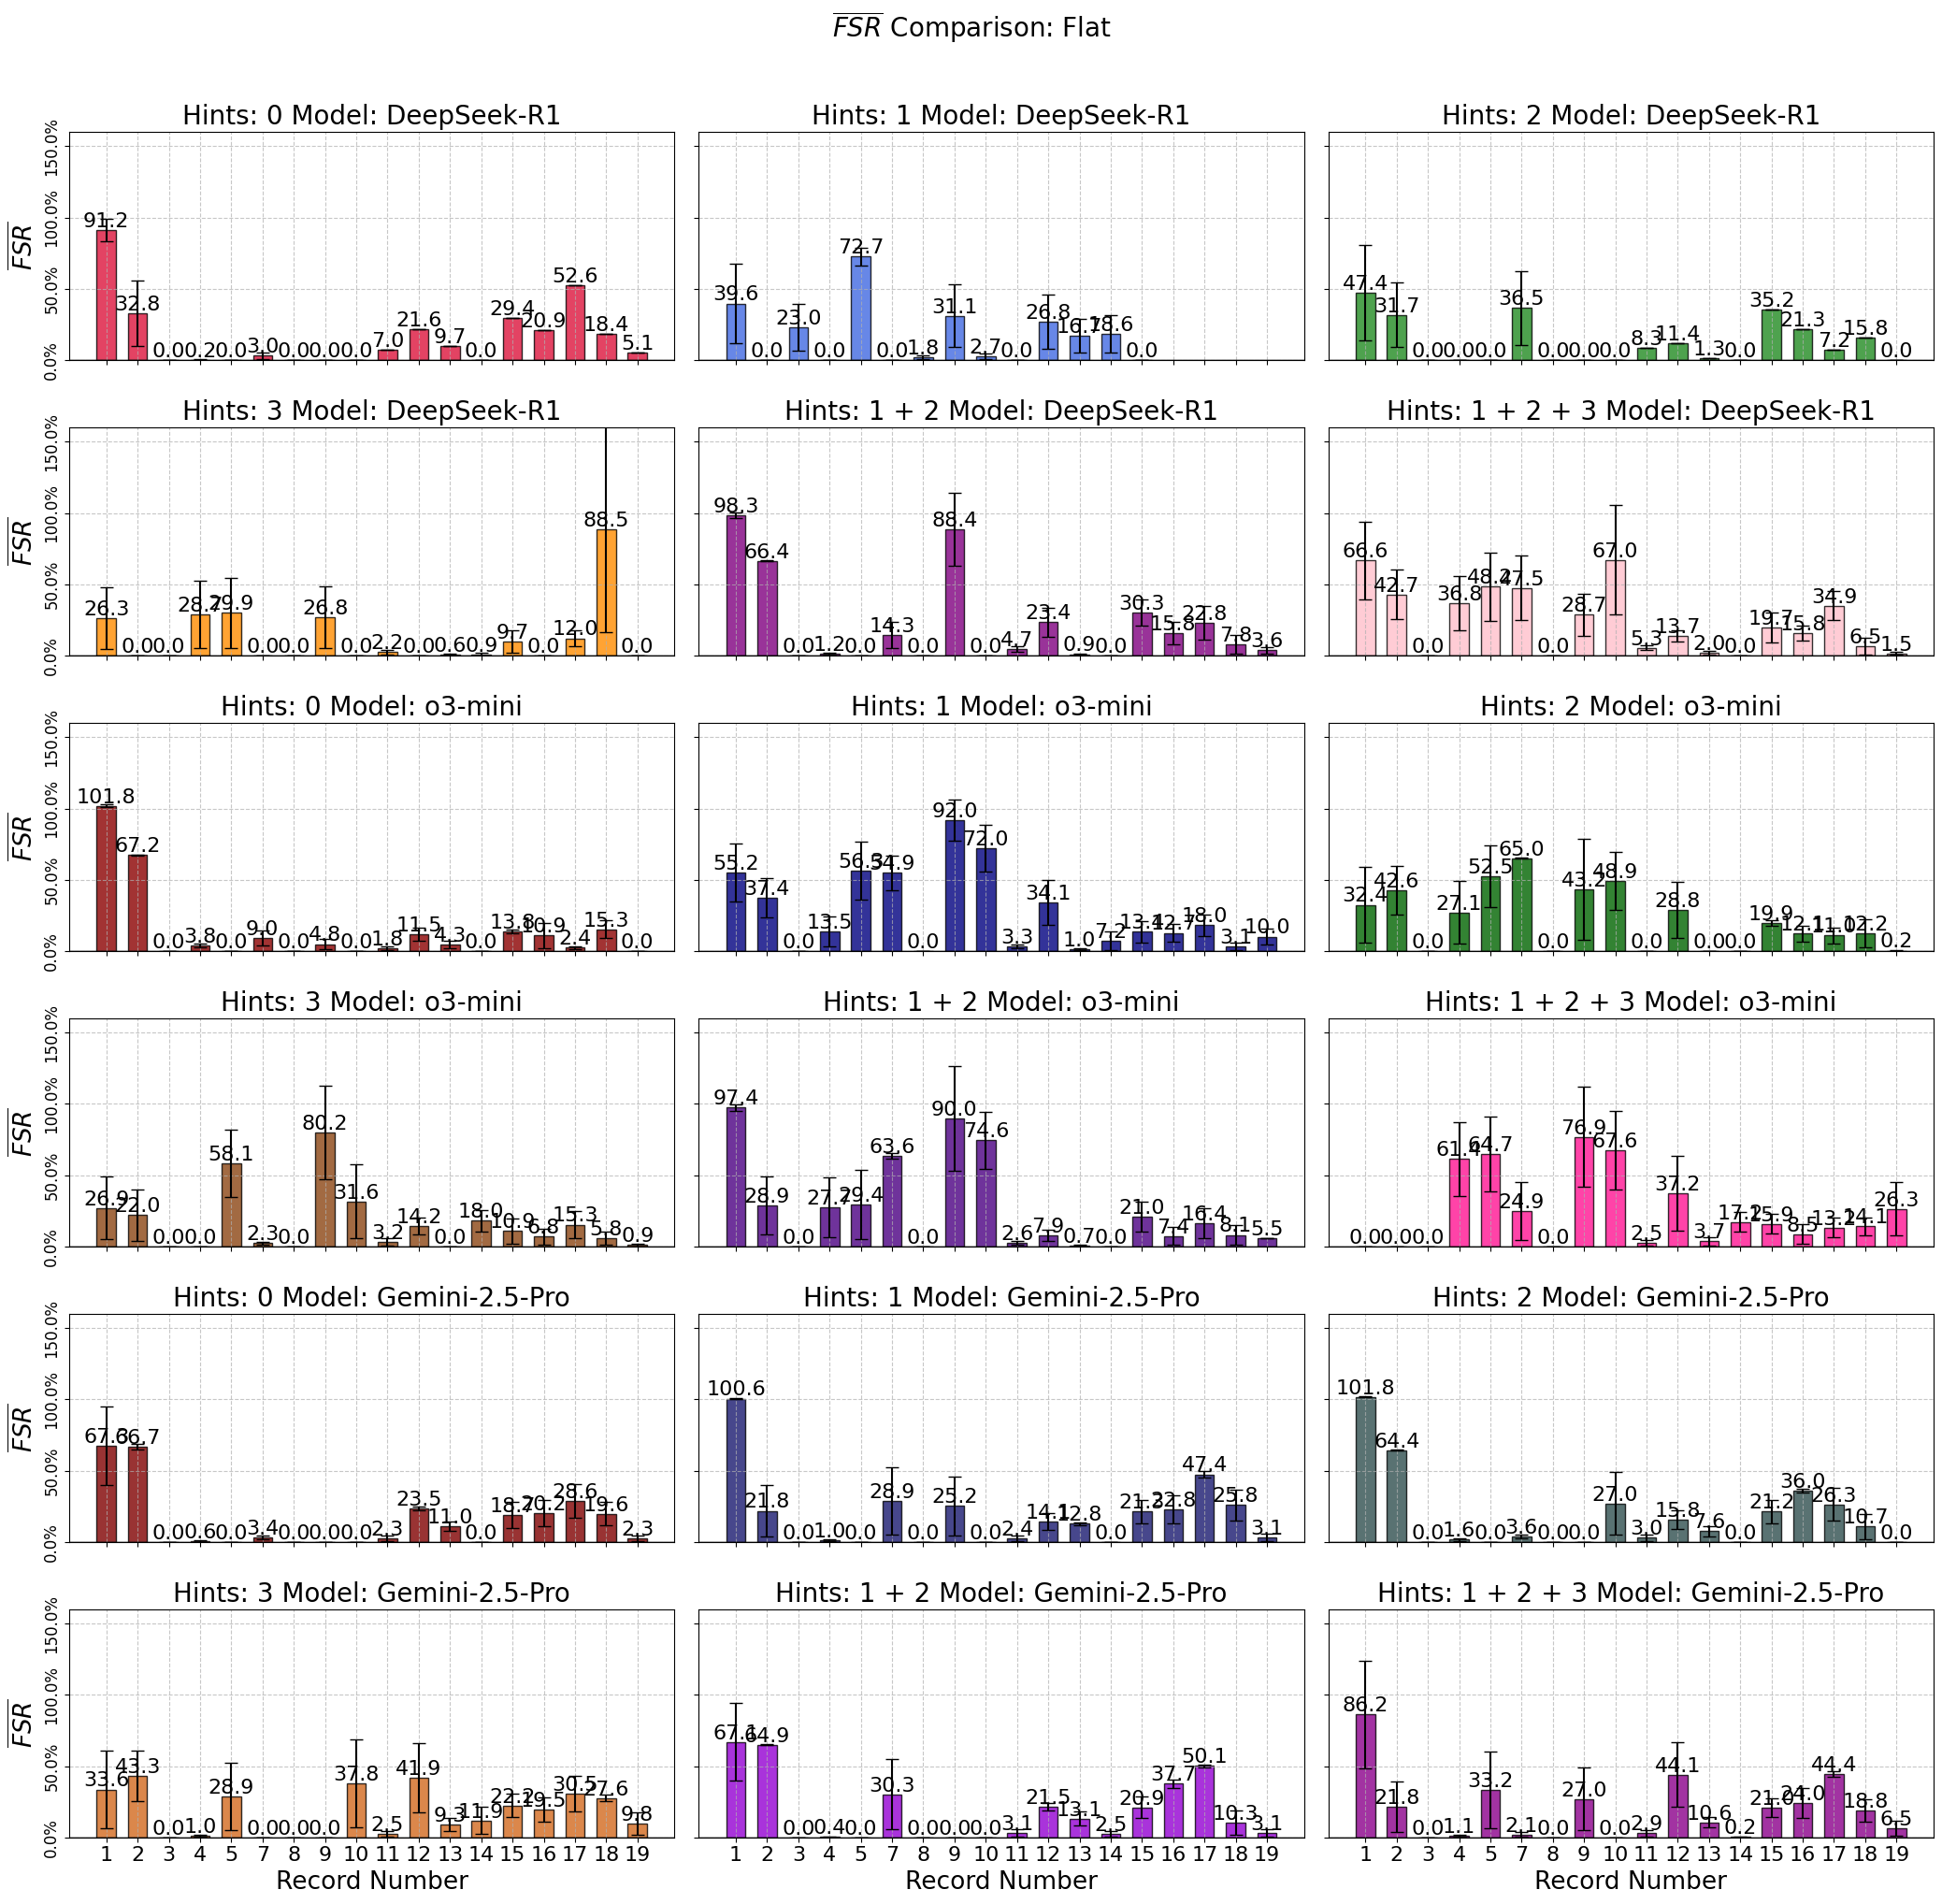

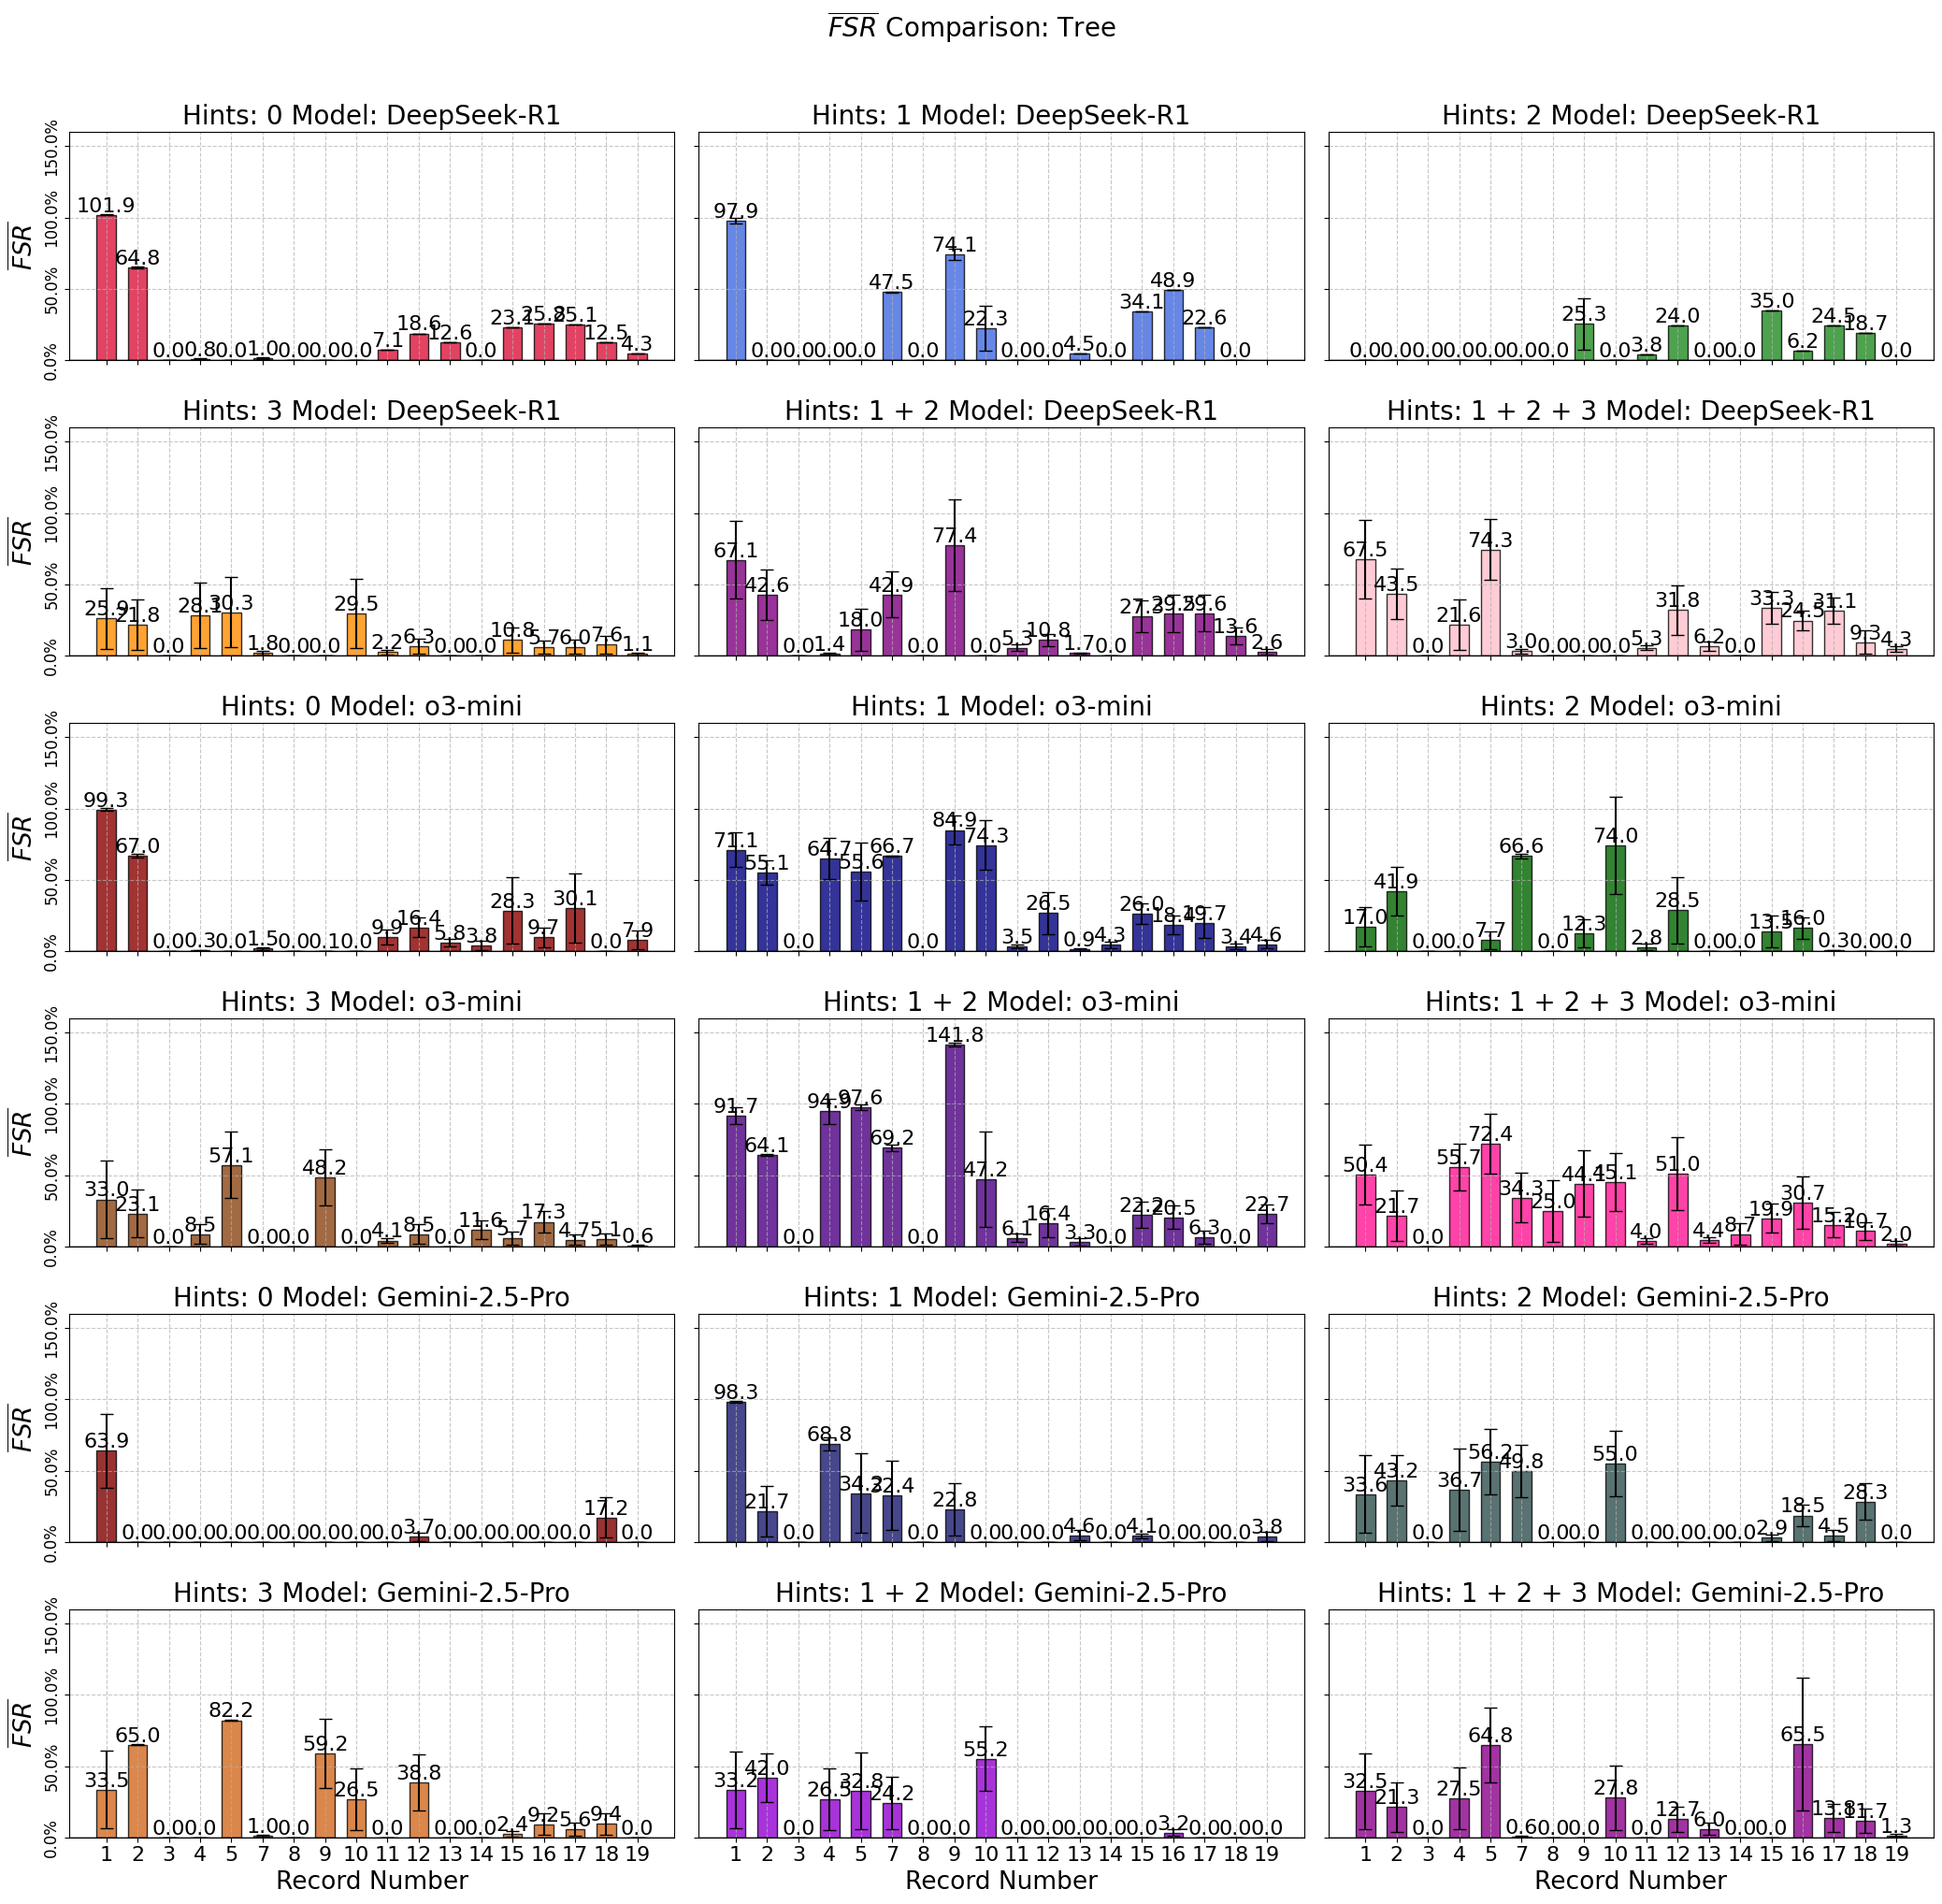

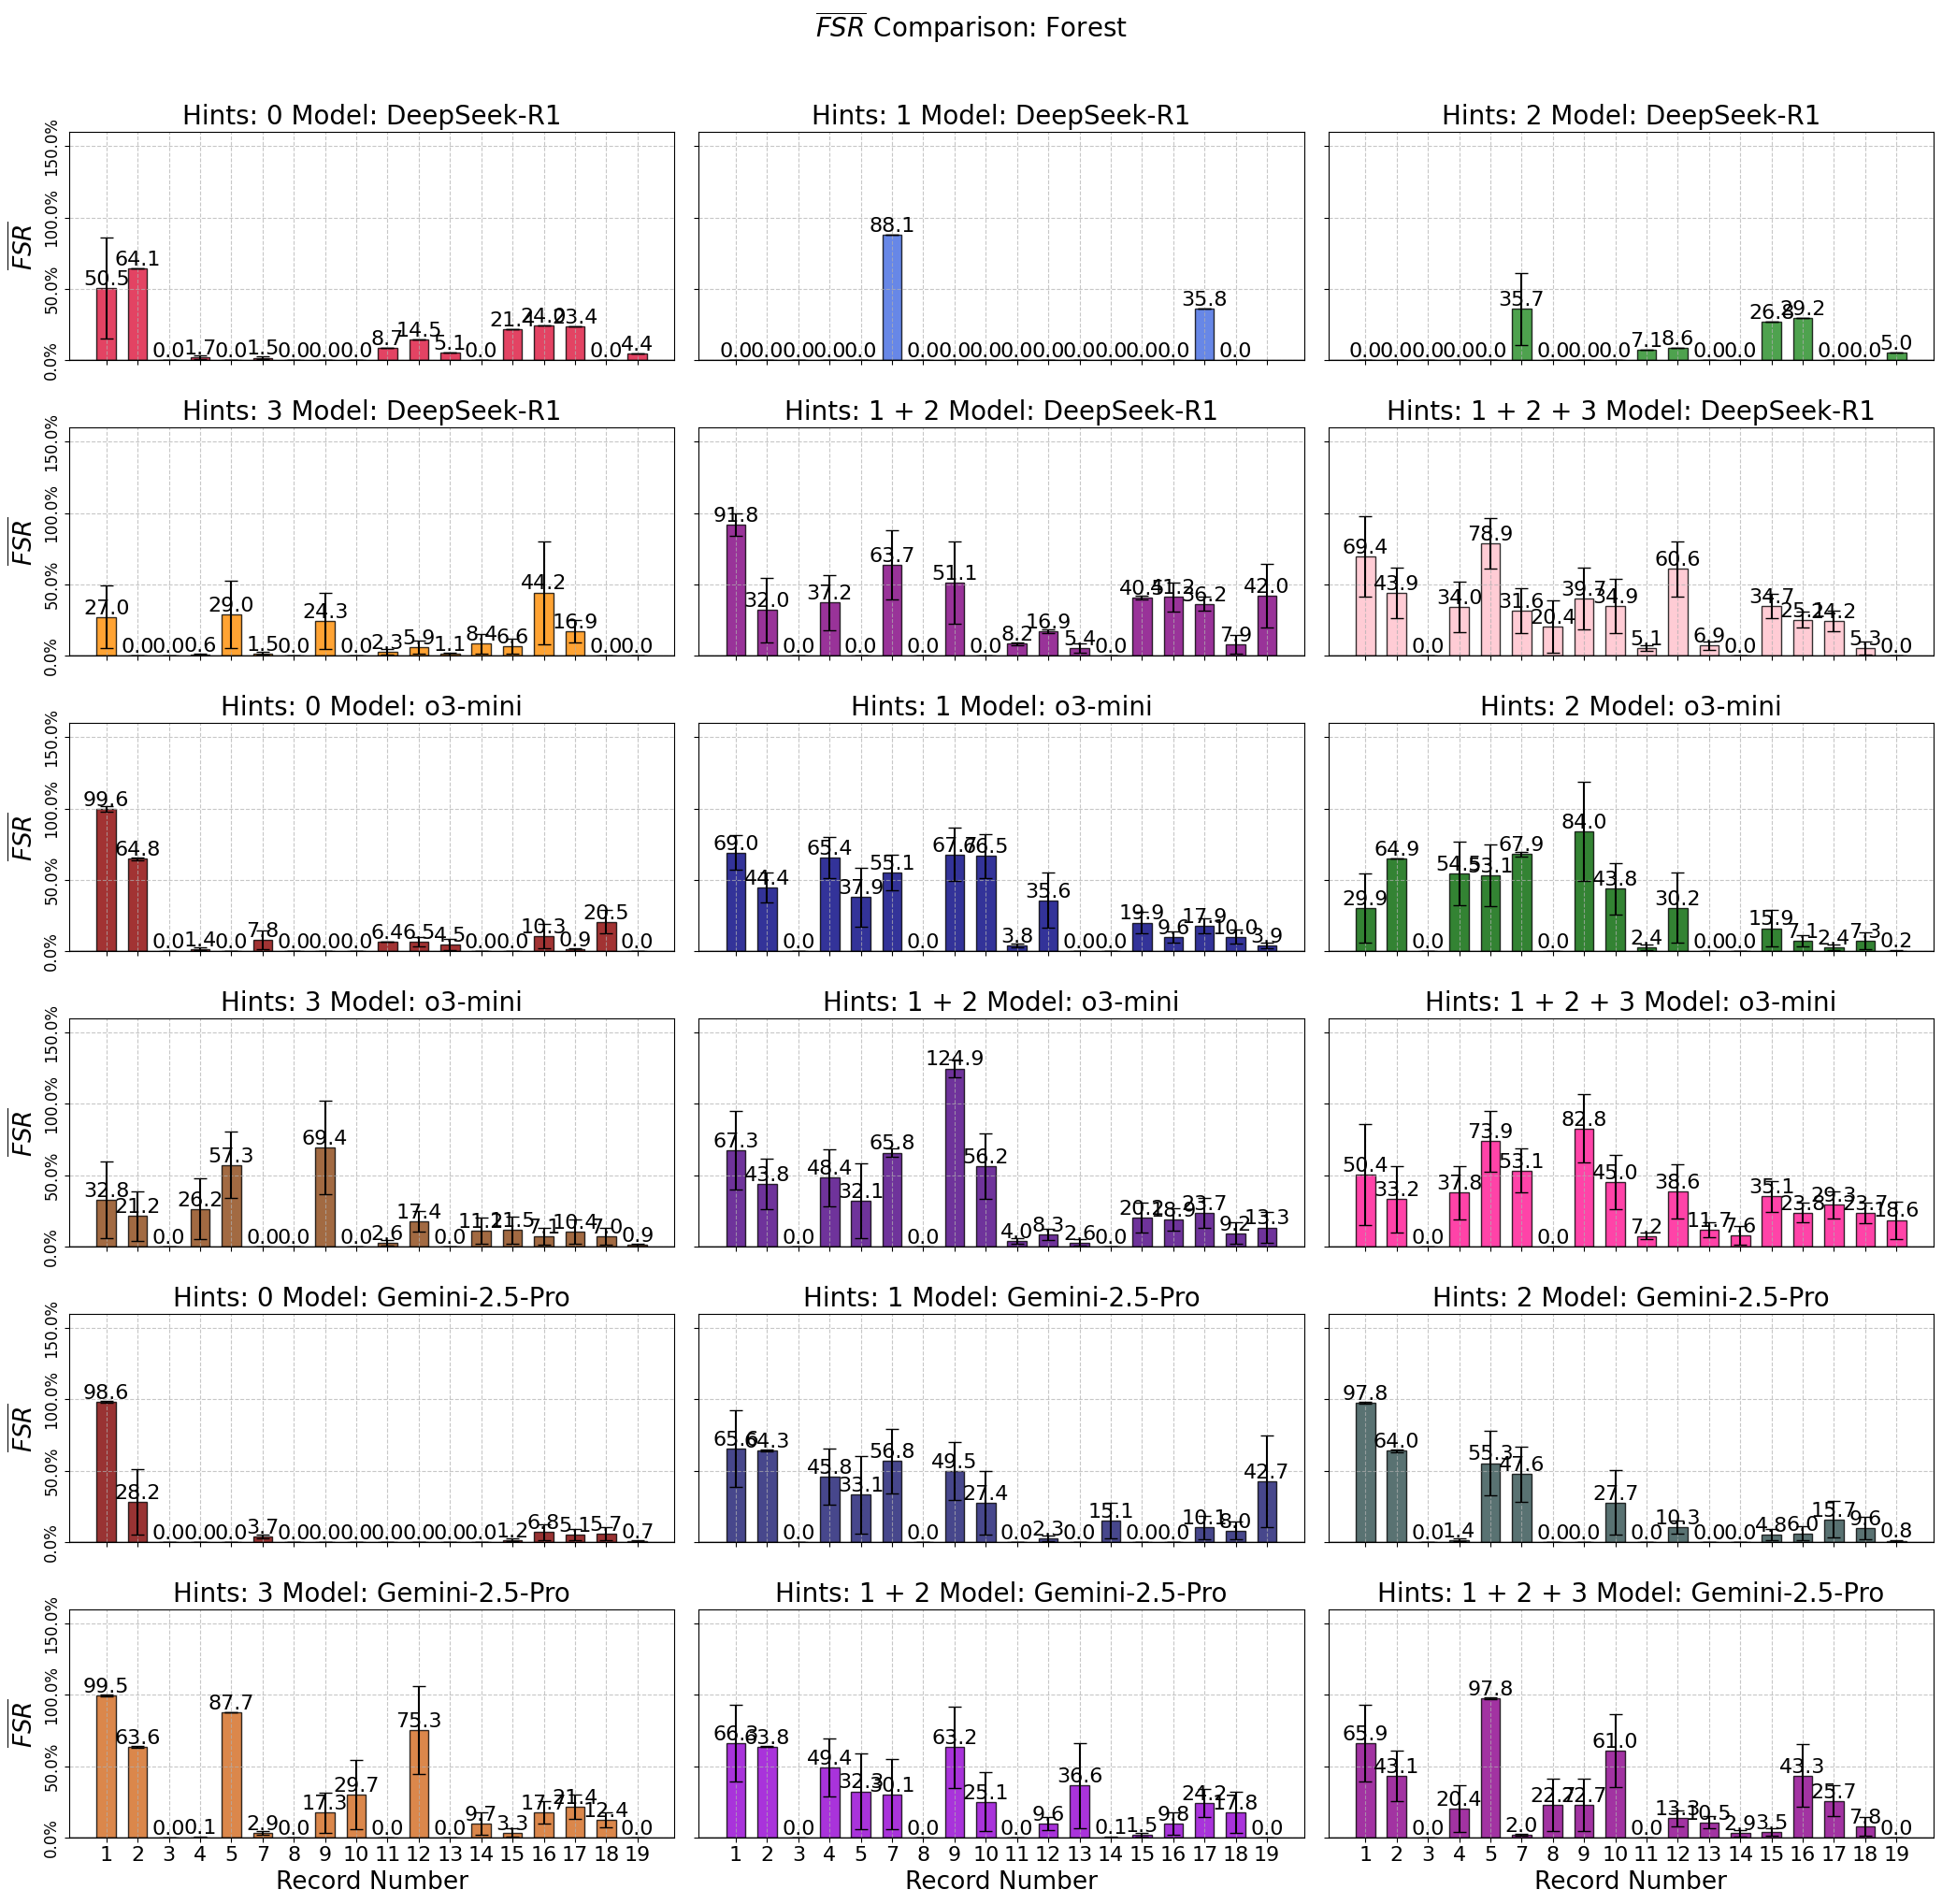

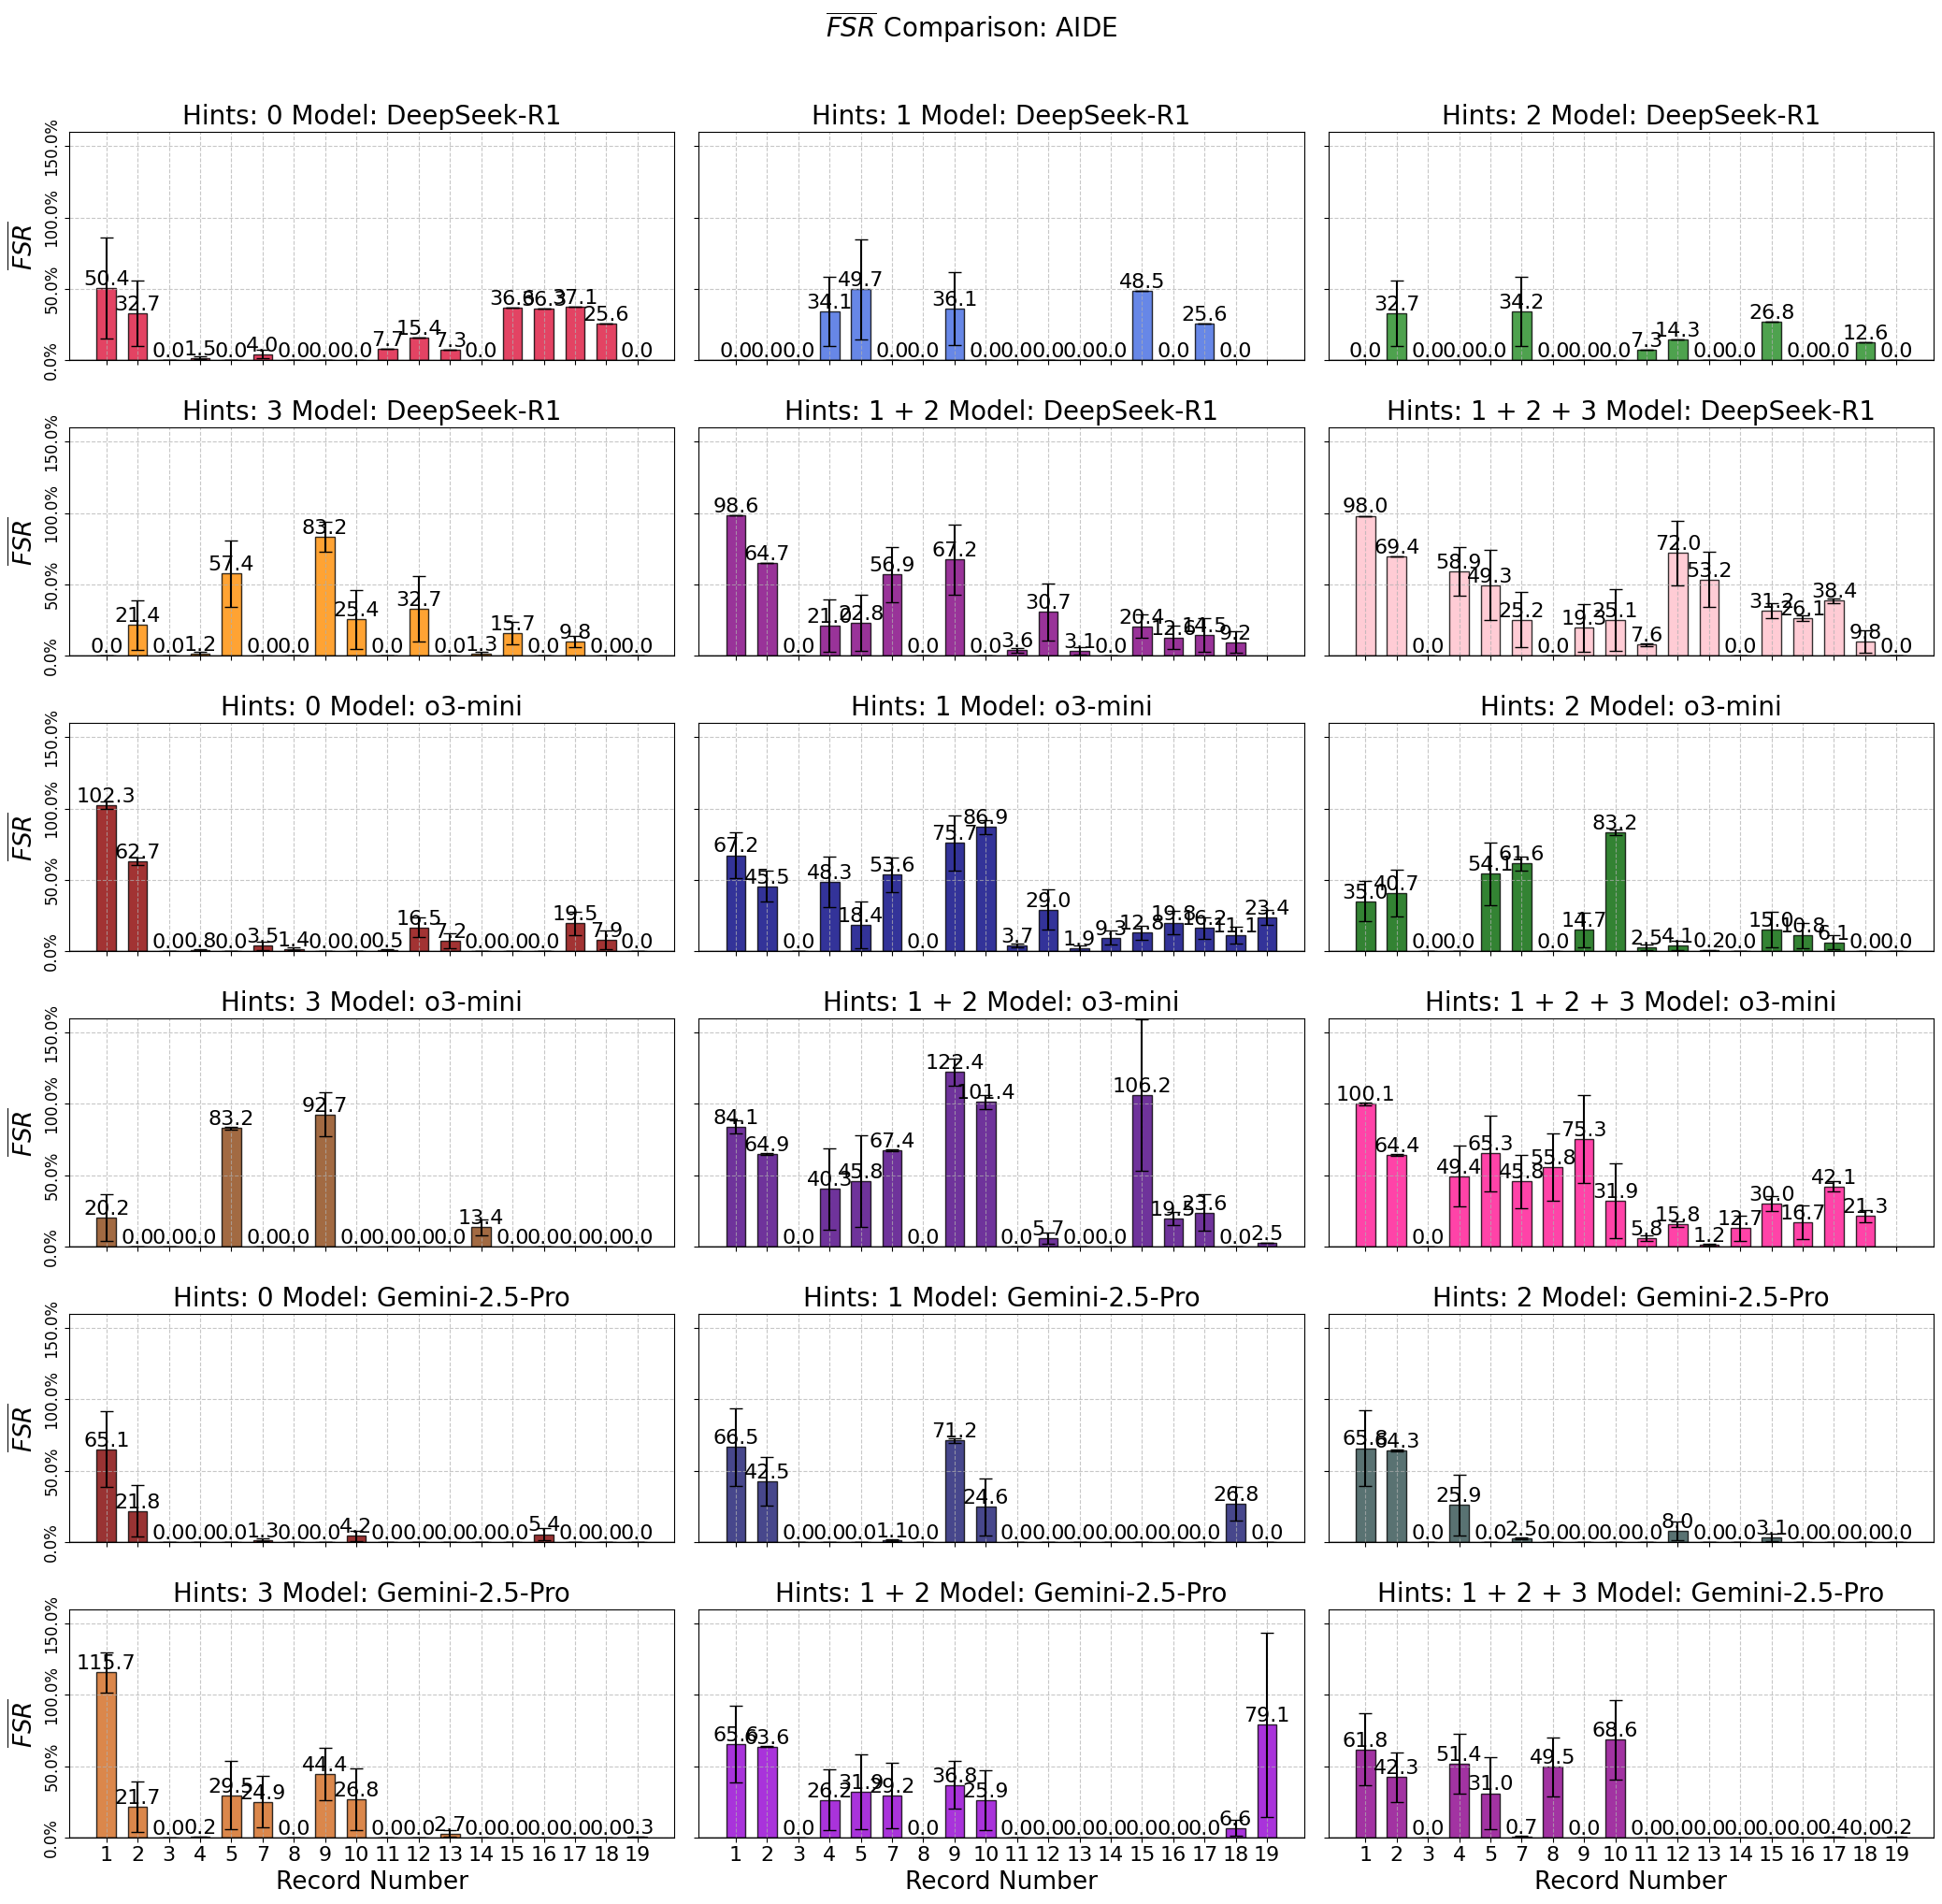

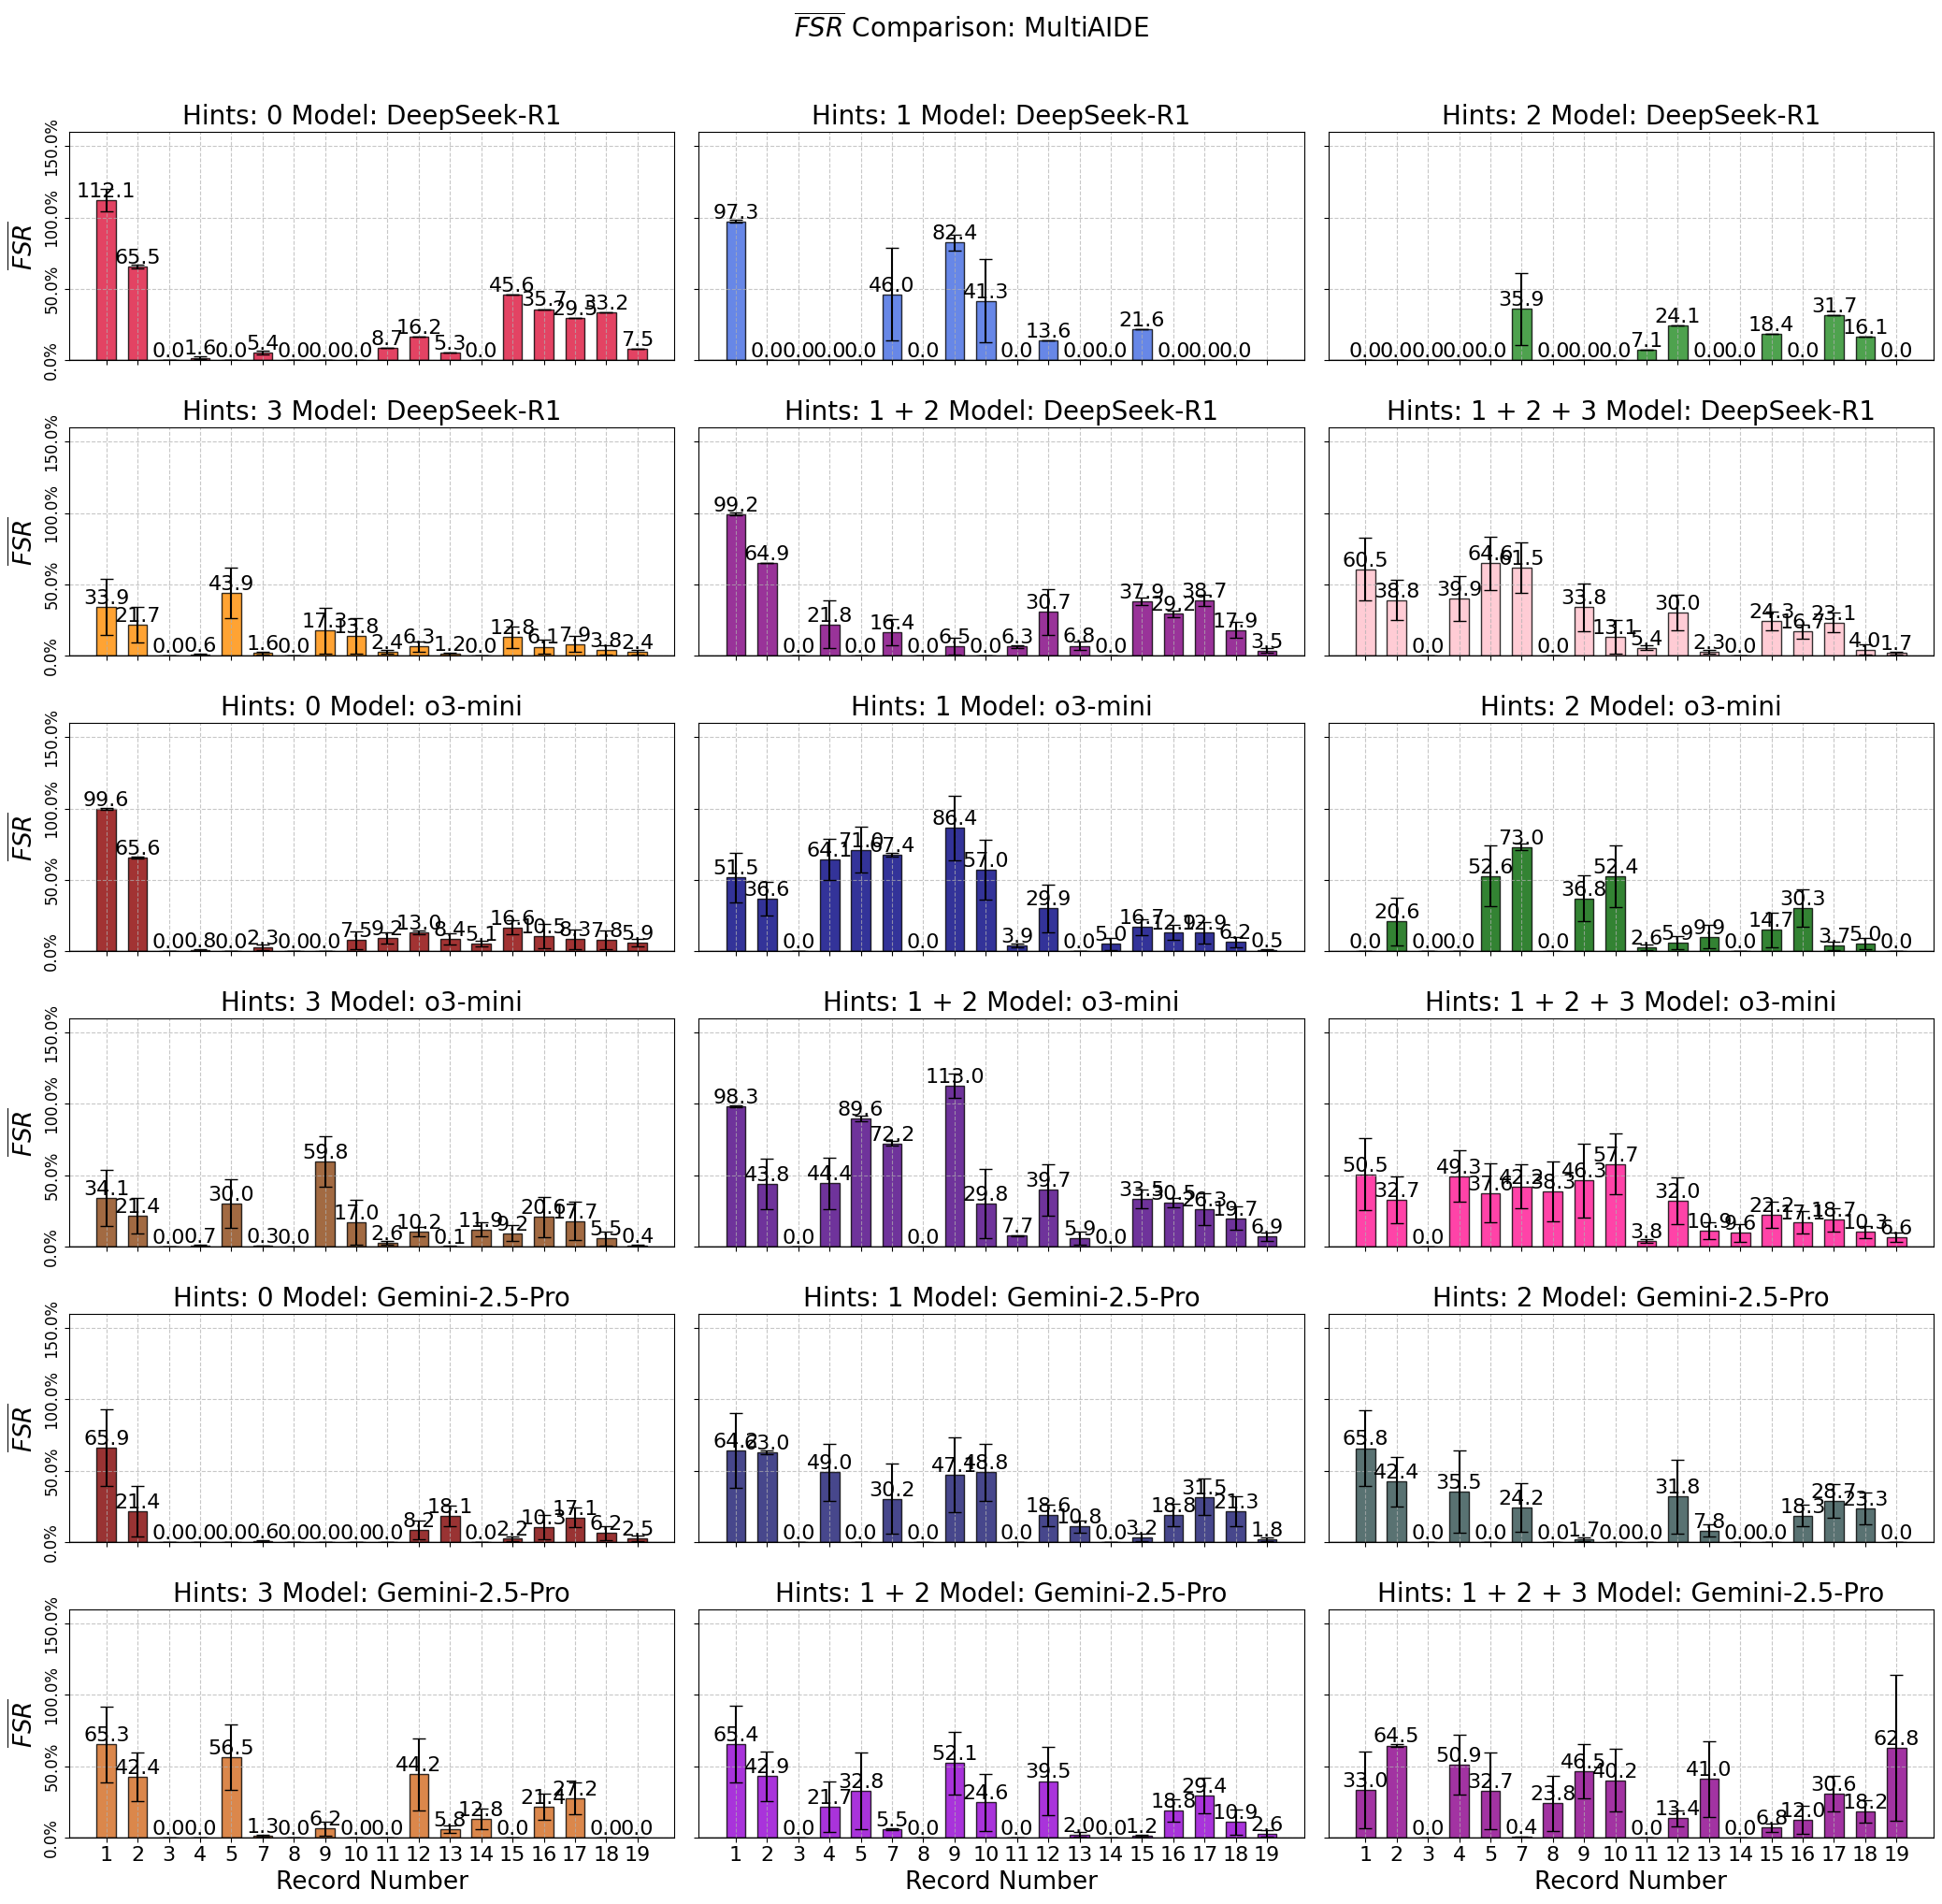

In [24]:
# get 6 colors and their darker versions
colors = ['crimson', 'royalblue', 'forestgreen', 'darkorange', 'purple', 'pink',
          'darkred', 'navy', 'darkgreen', 'saddlebrown', 'indigo', 'deeppink',
          'maroon', 'midnightblue', 'darkslategray', 'chocolate', 'darkviolet', 'darkmagenta']
search_algo_plot = {
    'flat': 'Flat',
    'tree': 'Tree',
    'forest': 'Forest',
    'aide': 'AIDE',
    'multi_aide': 'MultiAIDE',
}
model_plot = {
    'deepseek-r1': 'DeepSeek-R1',
    'o3-mini': 'o3-mini',
    'gemini-2.5-pro': 'Gemini-2.5-Pro',
}
level_plot = {
    'z': '0',
    1: '1',
    2: '2',
    5: '3',
    12: '1 + 2',
    125: '1 + 2 + 3',
}
for search_algo in ['flat', 'tree', 'forest', 'aide', 'multi_aide']:
    # filtered_figure_data = {k: v for k, v in figure_data.items() if search_algo in k}
    data_dicts = []
    data_stds = []
    i = 0
    for model in ('deepseek-r1', 'o3-mini', 'gemini-2.5-pro'):
        for level in ['z', 1, 2, 5, 12, 125]:
            filtered_figure_data = results_by_config[f'{search_algo}_{level}_{model}']['means']
            data_to_plot = {
                k: v['mean'] for k, v in filtered_figure_data.items()
            }
            std_to_plot = {
                k: v['sem'] for k, v in results_by_config[f'{search_algo}_{level}_{model}']['sems'].items()
            }
            data_dicts.append((
                data_to_plot,
                f'Hints: {level_plot[level]} Model: {model_plot[model]}',
                colors[i]
            ))
            data_stds.append(std_to_plot)
            i += 1
    plot_gap_comparison(
        data_dicts, 
        # std_dicts=std_percentage,
        data_stds=data_stds,
        figsize=(14, 7), 
        n_cols=3, 
        main_title='$\overline{FSR}$ Comparison:' + f' {search_algo_plot[search_algo]}'
    )
    plt.savefig(f'figures/{search_algo}_placeholder.pdf', dpi=200, bbox_inches='tight')

    #         data_dicts.append((
    #             filtered_figure_data[f'{search_algo}_{level}_{model}'], 
    #             f'hints: {level} model: {model}', 
    #             colors[i]
    #         ))
    #         i += 1
    # plot_gap_comparison(
    #     data_dicts, 
    #     std_dicts=std_percentage,
    #     figsize=(15, 10), 
    #     n_cols=3, 
    #     main_title=f'Recovered Time Gap Comparison: {search_algo}'
    # )
    # # plt.savefig(f'../figures/{search_algo}_placeholder.pdf', dpi=150)
    # plt.show()

